1.1  LOAD DATA DARI FILE EXCEL
Baris bahan makanan : 2295
Baris operasional   : 853
Total baris gabungan: 3148

Sampel 5 baris pertama:
 NO            ITEM    VOL SAT    BULAN MINGGU          TIPE
  1           Beras 1000.0  kg Oct 2025     W? Bahan Makanan
  2   Minyak Goreng   18.0 crt Oct 2025     W? Bahan Makanan
  3    Jamur Kuping    0.0  kg Oct 2025     W? Bahan Makanan
  4        Macaroni    0.0  kg Oct 2025     W? Bahan Makanan
  5 Mie Burung Dara    0.0 crt Oct 2025     W? Bahan Makanan

1.2  DATA DICTIONARY
 Kolom Tipe Data                                           Deskripsi        Contoh Null?
    NO       int                Nomor urut item dalam nota pembelian             1 Tidak
  ITEM       str            Nama bahan makanan atau item operasional         Beras Tidak
   VOL     float     Volume / jumlah pembelian pada periode tersebut          1100 Tidak
   SAT       str        Satuan pengukuran (kg, crt, pack, btl, dll.)            kg Tidak
 BULAN       str Bulan periode 

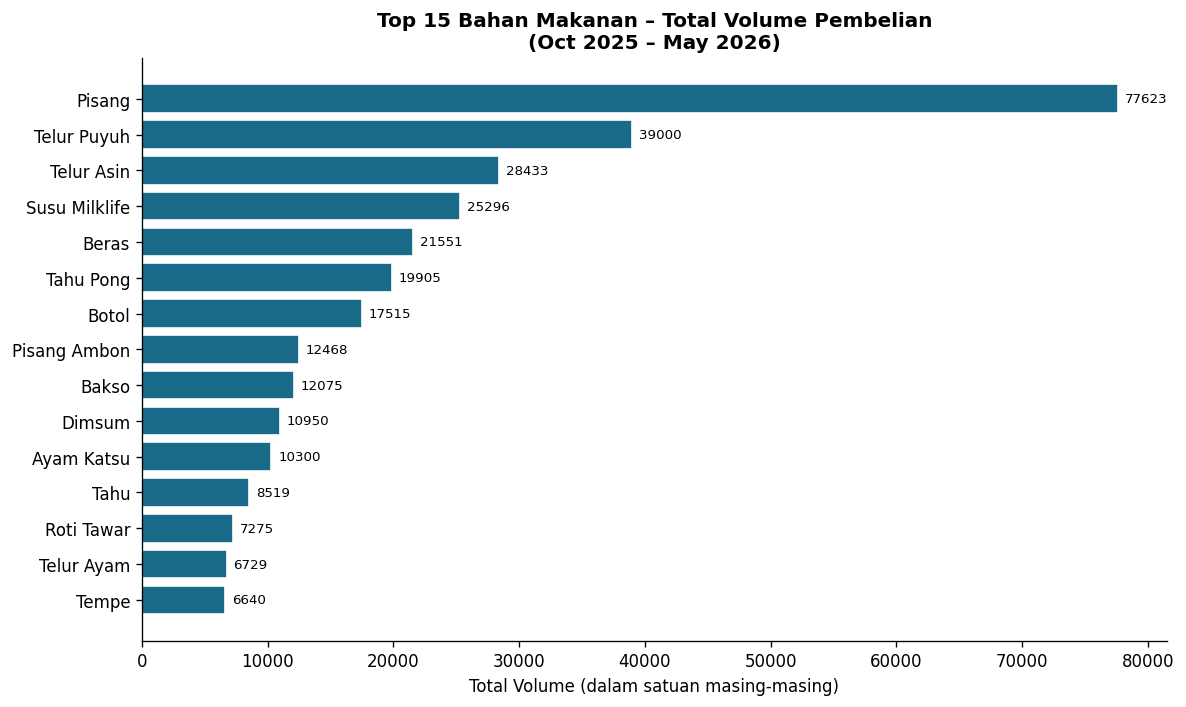

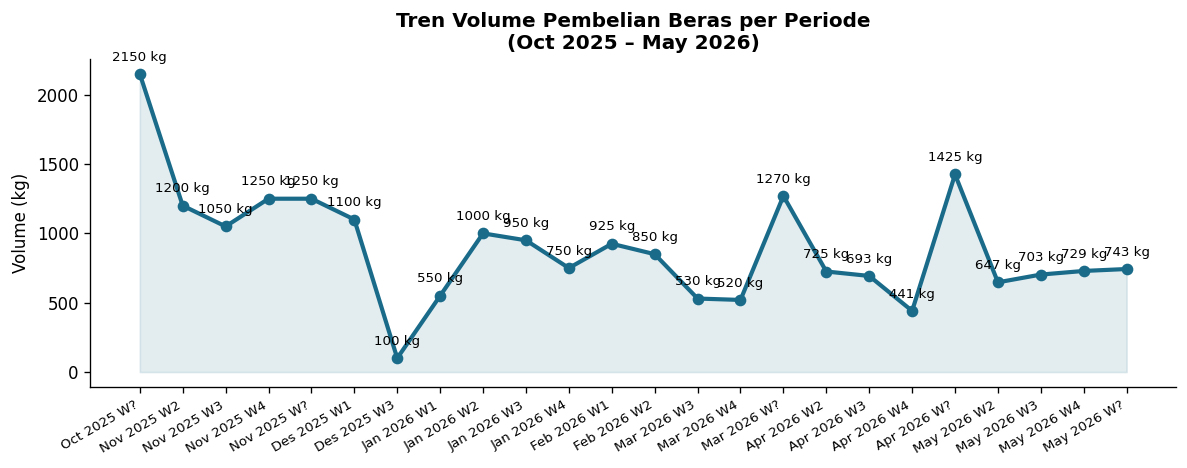

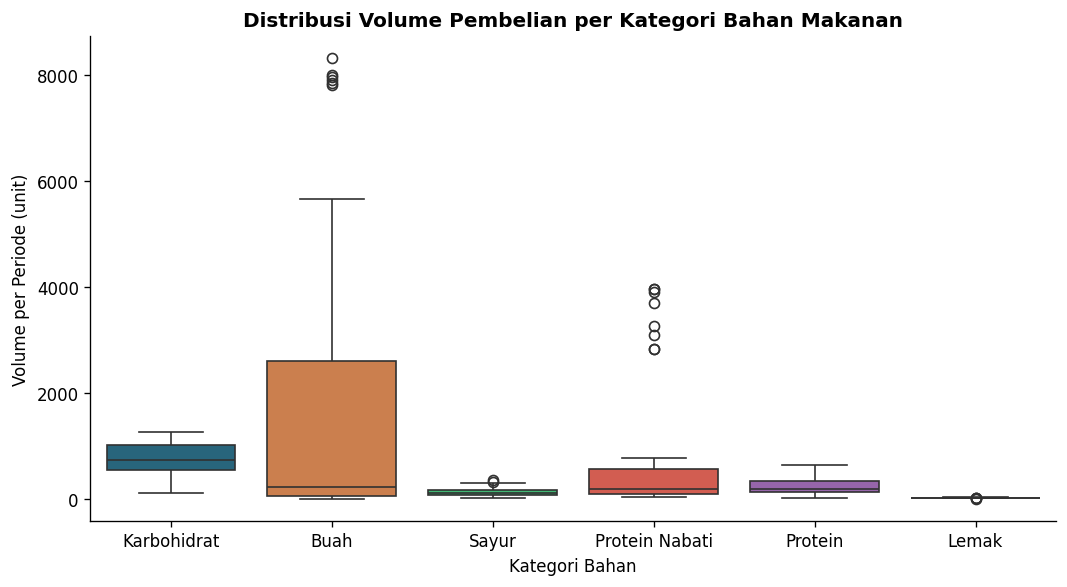

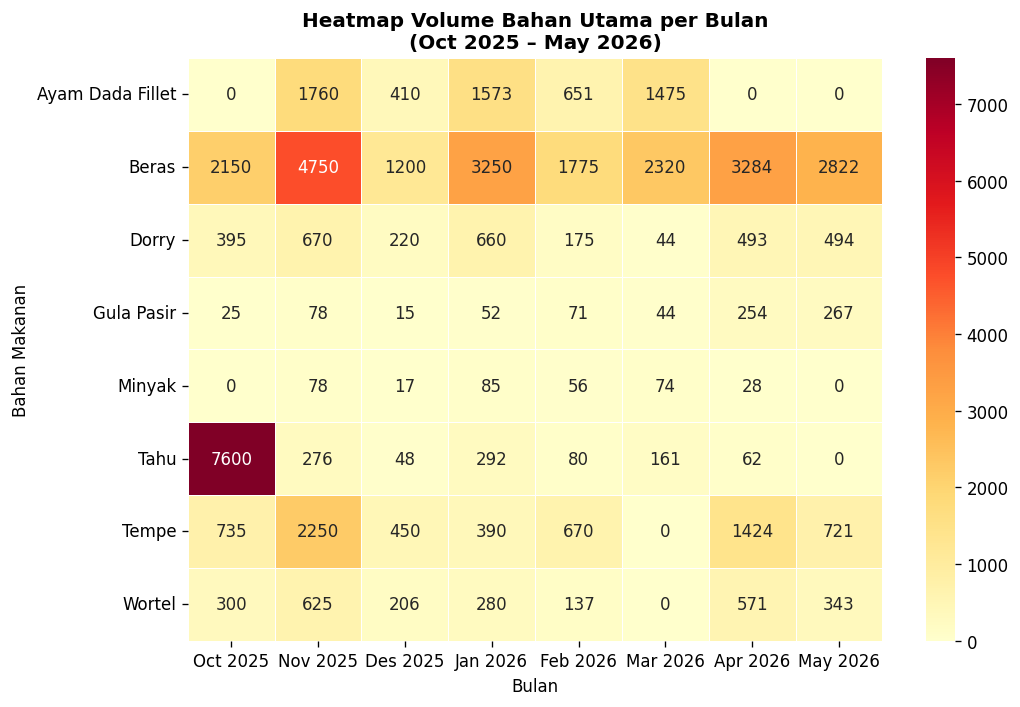

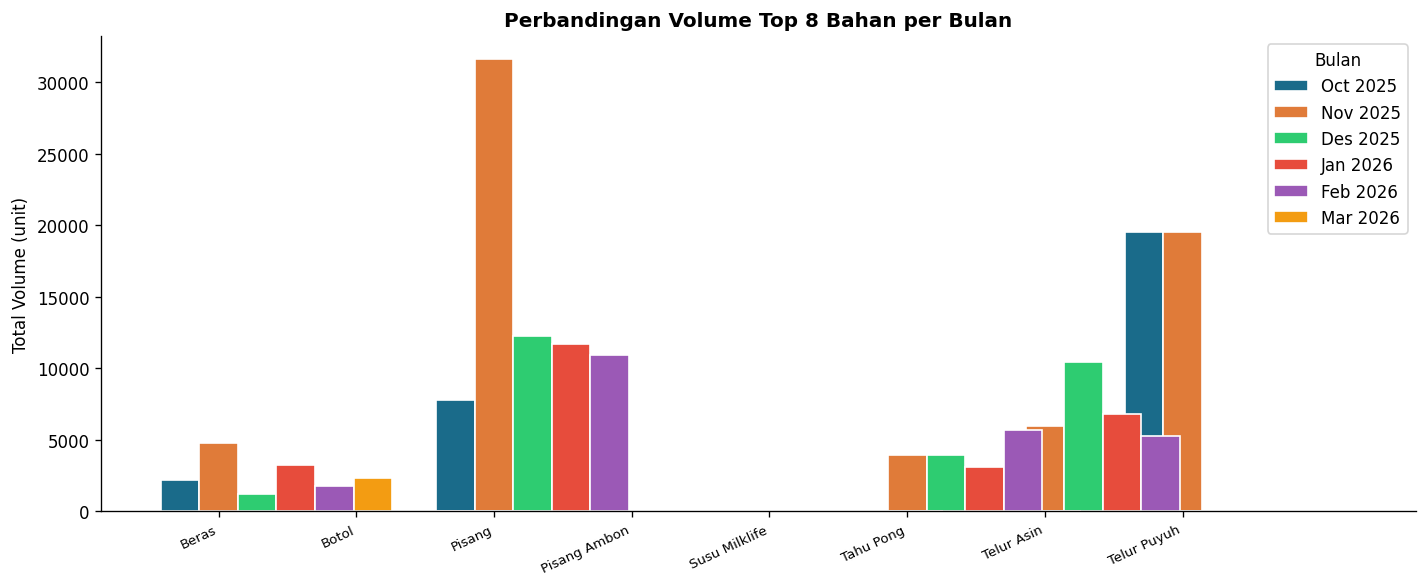

Data mentah tersimpan: raw_df_rekap.csv, raw_df_oprs.csv

BAGIAN 1 SELESAI


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# ── Styling global ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#1a6b8a', '#e07b39', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

DATA_DIR   = "/content/"
OUTPUT_DIR = "/mnt/user-data/outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==============================================================
# 1.1  LOAD DATA (Scraping dari Excel)
# ==============================================================
print("=" * 60)
print("1.1  LOAD DATA DARI FILE EXCEL")
print("=" * 60)

FILE_MAP = {
    "Oct 2025": DATA_DIR + "Rekap Nota Oct 2025.xlsx",
    "Nov 2025": DATA_DIR + "Rekap Nota Nov 2025.xlsx",
    "Des 2025": DATA_DIR + "Rekap Nota Dec 2025.xlsx",
    "Jan 2026": DATA_DIR + "Rekap Nota Jan 2026.xlsx",
    "Feb 2026": DATA_DIR + "Rekap Nota Feb 2026.xlsx",
    "Mar 2026": DATA_DIR + "Rekap Nota Mar 2026.xlsx",
    "Apr 2026": DATA_DIR + "Rekap Nota Apr 2026.xlsx",
    "May 2026": DATA_DIR + "Rekap Nota May 2026.xlsx",
}

# Mapping nama sheet → bulan & minggu
WEEK_DATES = {
    # Oct 2025
    "rekap 06 - 11 oktober 2025":    ("Oct 2025", "W1"),
    "oprs 06 - 11 oktober 2025":     ("Oct 2025", "W1"),
    "rekap 13 - 18 oktober 2025":    ("Oct 2025", "W2"),
    "oprs 13 - 18 oktober 2025":     ("Oct 2025", "W2"),
    "rekap 20 - 25 oktober 2025":    ("Oct 2025", "W3"),
    "oprs 20 - 25 oktober 2025":     ("Oct 2025", "W3"),
    "rekap 27 - 31 oktober 2025":    ("Oct 2025", "W4"),
    "oprs 27 - 31 oktober 2025":     ("Oct 2025", "W4"),

    # Nov 2025
    "rekap 03 - 08 november 2025":   ("Nov 2025", "W1"),
    "oprs 03 - 08 november 2025":    ("Nov 2025", "W1"),
    "rekap 10 - 15 november 2025":   ("Nov 2025", "W2"),
    "oprs 10 - 15 november 2025":    ("Nov 2025", "W2"),
    "rekap 17 - 22 november 2025":   ("Nov 2025", "W3"),
    "oprs 17 - 22 november 2025":    ("Nov 2025", "W3"),
    "rekap 24 - 29 november 2025":   ("Nov 2025", "W4"),
    "oprs 24 - 29 november 2025":    ("Nov 2025", "W4"),

    # Des 2025
    "rekap 1 - 6 desember 2025":     ("Des 2025", "W1"),
    "oprs 1 - 6 desember 2025":      ("Des 2025", "W1"),
    "rekap 8 - 13 desember 2025":    ("Des 2025", "W2"),
    "oprs 8 - 13 desember 2025":     ("Des 2025", "W2"),
    "rekap 22 - 31 desember 2025":   ("Des 2025", "W3"),
    "oprs 22 - 31 desember 2025":    ("Des 2025", "W3"),

    # Jan 2026
    "rekap 5 - 10 januari 2026":     ("Jan 2026", "W1"),
    "oprs 5 - 10 januari 2026":      ("Jan 2026", "W1"),
    "rekap 12 - 17 januari 2026":    ("Jan 2026", "W2"),
    "oprs 12 - 17 januari 2026":     ("Jan 2026", "W2"),
    "rekap 19 - 24 januari 2026":    ("Jan 2026", "W3"),
    "oprs 19 - 24 januari 2026":     ("Jan 2026", "W3"),
    "rekap 26 - 31 januari 2026":    ("Jan 2026", "W4"),
    "oprs 26 - 31 januari 2026":     ("Jan 2026", "W4"),

    # Feb 2026
    "rekap 02 - 07 feb 2026":        ("Feb 2026", "W1"),
    "oprs 02 - 07 feb 2026":         ("Feb 2026", "W1"),
    "rekap 09 - 14 feb 2026":        ("Feb 2026", "W2"),
    "oprs 09 - 14 feb 2026":         ("Feb 2026", "W2"),
    "rekap 23 - 28 feb 2026":        ("Feb 2026", "W3"),
    "oprs 23 - 28 feb 2026":         ("Feb 2026", "W3"),

    # Mar 2026
    "rekap 02 - 07 maret 2026":      ("Mar 2026", "W1"),
    "oprs 02 - 07 maret 2026":       ("Mar 2026", "W1"),
    "rekap 09 - 14 maret 2026":      ("Mar 2026", "W2"),
    "oprs 09 - 14 maret 2026":       ("Mar 2026", "W2"),
    "rekap 16 - 21 maret 2026":      ("Mar 2026", "W3"),
    "oprs 16 - 21 maret 2026":       ("Mar 2026", "W3"),
    "rekap 23 - 28 maret 2026":      ("Mar 2026", "W4"),
    "oprs 23 - 28 maret 2026":       ("Mar 2026", "W4"),

    # Apr 2026
    "rekap 06 - 11 april 2026":      ("Apr 2026", "W1"),
    "oprs 06 - 11 april 2026":       ("Apr 2026", "W1"),
    "rekap 13 - 18 april 2026":      ("Apr 2026", "W2"),
    "oprs 13 - 18 april 2026":       ("Apr 2026", "W2"),
    "rekap 20 - 25 april 2026":      ("Apr 2026", "W3"),
    "oprs 20 - 25 april 2026":       ("Apr 2026", "W3"),
    "rekap 27 - 30 april 2026":      ("Apr 2026", "W4"),
    "oprs 27 - 30 april 2026":       ("Apr 2026", "W4"),

    # May 2026
    "rekap 04 - 09 mei 2026":        ("May 2026", "W1"),
    "oprs 04 - 09 mei 2026":         ("May 2026", "W1"),
    "rekap 11 - 16 mei 2026":        ("May 2026", "W2"),
    "oprs 11 - 16 mei 2026":         ("May 2026", "W2"),
    "rekap 18 - 23 mei 2026":        ("May 2026", "W3"),
    "oprs 18 - 23 mei 2026":         ("May 2026", "W3"),
    "rekap 25 - 30 mei 2026":        ("May 2026", "W4"),
    "oprs 25 - 30 mei 2026":         ("May 2026", "W4"),
}

rekap_frames = []
oprs_frames  = []

for label, path in FILE_MAP.items():
    xl = pd.read_excel(path, sheet_name=None)
    for sheet_name, df in xl.items():
        if df.shape[1] < 3:
            continue
        df = df.rename(columns=lambda c: str(c).strip().upper())
        df = df[df['ITEM'].notna() & (df['ITEM'].astype(str).str.strip() != '')]
        df['ITEM'] = df['ITEM'].astype(str).str.strip().str.title()
        df['VOL']  = pd.to_numeric(df['VOL'], errors='coerce').fillna(0)
        df['BULAN'] = label

        # Tentukan minggu dari nama sheet
        key = sheet_name.strip().lower()
        matched = False
        for pattern, (bln, wk) in WEEK_DATES.items():
            if pattern in key:
                df['MINGGU'] = wk
                matched = True
                break
        if not matched:
            df['MINGGU'] = "W?"

        if sheet_name.lower().startswith('rekap'):
            df['TIPE'] = 'Bahan Makanan'
            rekap_frames.append(df)
        elif sheet_name.lower().startswith('oprs'):
            df['TIPE'] = 'Operasional'
            oprs_frames.append(df)

df_rekap = pd.concat(rekap_frames, ignore_index=True)
df_oprs  = pd.concat(oprs_frames,  ignore_index=True)
df_all   = pd.concat([df_rekap, df_oprs], ignore_index=True)

print(f"Baris bahan makanan : {len(df_rekap)}")
print(f"Baris operasional   : {len(df_oprs)}")
print(f"Total baris gabungan: {len(df_all)}")
print(f"\nSampel 5 baris pertama:\n{df_rekap.head().to_string(index=False)}")

# ==============================================================
# 1.2  DATA DICTIONARY
# ==============================================================
print("\n" + "=" * 60)
print("1.2  DATA DICTIONARY")
print("=" * 60)

dd = pd.DataFrame({
    'Kolom'     : ['NO', 'ITEM', 'VOL', 'SAT', 'BULAN', 'MINGGU', 'TIPE'],
    'Tipe Data' : ['int', 'str', 'float', 'str', 'str', 'str', 'str'],
    'Deskripsi' : [
        'Nomor urut item dalam nota pembelian',
        'Nama bahan makanan atau item operasional',
        'Volume / jumlah pembelian pada periode tersebut',
        'Satuan pengukuran (kg, crt, pack, btl, dll.)',
        'Bulan periode pembelian (Oct 2025 / ... / May 2026)', # Updated description
        'Minggu ke- dalam bulan (W1 / W2 / W3 / W4)',
        'Kategori item: Bahan Makanan atau Operasional',
    ],
    'Contoh'    : ['1', 'Beras', '1100', 'kg', 'Des 2025', 'W1', 'Bahan Makanan'],
    'Null?'     : ['Tidak', 'Tidak', 'Tidak', 'Tidak', 'Tidak', 'Tidak', 'Tidak'],
})
print(dd.to_string(index=False))

# ==============================================================
# 1.3  HASIL EDA – STATISTIK DESKRIPTIF
# ==============================================================
print("\n" + "=" * 60)
print("1.3  HASIL EDA – STATISTIK DESKRIPTIF")
print("=" * 60)

df_eda = df_rekap[df_rekap['VOL'] > 0].copy()

print(f"\n── Ringkasan Volume (VOL > 0) ──")
print(df_eda['VOL'].describe().round(2).to_string())

print(f"\n── Jumlah Item Unik       : {df_eda['ITEM'].nunique()}")
print(f"── Periode yang Tercakup  : {df_eda['BULAN'].nunique()} bulan")
print(f"── Distribusi per Bulan   :")
print(df_eda['BULAN'].value_counts().to_string())

print(f"\n── Top 10 Bahan Terbanyak (by total volume) ──")
top10 = df_eda.groupby('ITEM')['VOL'].sum().sort_values(ascending=False).head(10)
print(top10.to_string())

print(f"\n── Distribusi Satuan (SAT) ──")
print(df_eda['SAT'].value_counts().head(10).to_string())

# ==============================================================
# 1.4  VISUALISASI EDA
# ==============================================================
print("\n" + "=" * 60)
print("1.4  VISUALISASI EDA")
print("=" * 60)

# ── Normalisasi nama untuk visualisasi ──
nama_map = {
    'Beras Jbs'          : 'Beras',
    'Dorry Nasuba'       : 'Dorry',
    'Dorry'              : 'Dorry',
    'Minyak Fortune'     : 'Minyak',
    'Minyak Sunco'       : 'Minyak',
    'Vetsin Ajinomoto'   : 'Vetsin',
    'Garam Dolphin'      : 'Garam',
    'Roycko Ayam'        : 'Roycko',
    'Lada Bubuk Ladaku'  : 'Lada Bubuk',
    'Tepung Terigu Segitiga Biru': 'Tepung Terigu',
}
df_eda['ITEM_NORM'] = df_eda['ITEM'].replace(nama_map).fillna(df_eda['ITEM'])

## ── 1.4.1  Top 15 Bahan by Total Volume ──────────────────────
top15 = (df_eda.groupby('ITEM_NORM')['VOL'].sum()
               .sort_values(ascending=False)
               .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15.index[::-1], top15.values[::-1],
               color=PALETTE[0], edgecolor='white')
ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=8)
ax.set_xlabel('Total Volume (dalam satuan masing-masing)', fontsize=10)
ax.set_title('Top 15 Bahan Makanan – Total Volume Pembelian\n(Oct 2025 – May 2026)', # Updated title
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# plt.savefig(OUTPUT_DIR + "eda_top15_bahan.png", bbox_inches='tight')
# plt.close()

## 1.4.2  Tren Volume Beras per Periode ─────────────────────
urutan_bulan = ['Oct 2025', 'Nov 2025', 'Des 2025', 'Jan 2026', 'Feb 2026', 'Mar 2026', 'Apr 2026', 'May 2026'] # Updated urutan_bulan
df_eda['BULAN_ORD']  = df_eda['BULAN'].map({b: i for i, b in enumerate(urutan_bulan)})
df_eda['MINGGU_ORD'] = df_eda['MINGGU'].map({'W1':1,'W2':2,'W3':3,'W4':4})
df_eda['PERIODE']    = df_eda['BULAN'] + ' ' + df_eda['MINGGU']
# urutkan berdasarkan ordinal
df_eda = df_eda.sort_values(['BULAN_ORD','MINGGU_ORD'])

beras_trend = (df_eda[df_eda['ITEM_NORM'] == 'Beras']
               .groupby('PERIODE')['VOL'].sum())
# Urutkan periode sesuai urutan sebenarnya
periode_order = df_eda.drop_duplicates('PERIODE').set_index('PERIODE')[['BULAN_ORD','MINGGU_ORD']]
beras_trend = beras_trend.reindex(
    periode_order.sort_values(['BULAN_ORD','MINGGU_ORD']).index
).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(beras_trend)), beras_trend.values,
        marker='o', color=PALETTE[0], linewidth=2.5)
ax.fill_between(range(len(beras_trend)), beras_trend.values,
                alpha=0.12, color=PALETTE[0])
for i, (x, y) in enumerate(zip(range(len(beras_trend)), beras_trend.values)):
    ax.annotate(f'{int(y)} kg', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)
ax.set_xticks(range(len(beras_trend)))
ax.set_xticklabels(beras_trend.index, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Volume (kg)')
ax.set_title('Tren Volume Pembelian Beras per Periode\n(Oct 2025 – May 2026)', # Updated title
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# plt.savefig(OUTPUT_DIR + "eda_tren_beras.png", bbox_inches='tight')
# plt.close()

## ── 1.4.3  Boxplot Distribusi per Kategori Bahan ─────────────
kategori_map = {
    'Beras': 'Karbohidrat', 'Minyak': 'Lemak',
    'Ayam Dada Fillet': 'Protein', 'Beef Slice': 'Protein',
    'Dorry': 'Protein', 'Dorry Nasuba': 'Protein',
    'Tempe': 'Protein Nabati', 'Tahu': 'Protein Nabati', 'Tahu Pong': 'Protein Nabati',
    'Wortel': 'Sayur', 'Sawi Putih': 'Sayur', 'Sawi Bakso': 'Sayur',
    'Timun': 'Sayur', 'Selada': 'Sayur', 'Kembang Kol': 'Sayur',
    'Jeruk': 'Buah', 'Anggur': 'Buah', 'Pisang': 'Buah',
}
df_eda['KATEGORI'] = df_eda['ITEM_NORM'].map(kategori_map)
df_kat = df_eda[df_eda['KATEGORI'].notna()]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_kat, x='KATEGORI', y='VOL', palette=PALETTE, ax=ax)
ax.set_xlabel('Kategori Bahan')
ax.set_ylabel('Volume per Periode (unit)')
ax.set_title('Distribusi Volume Pembelian per Kategori Bahan Makanan',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# plt.savefig(OUTPUT_DIR + "eda_distribusi_kategori.png", bbox_inches='tight')
# plt.close()

## ── 1.4.4  Heatmap Volume Bahan Utama per Bulan ──────────────
pivot_items = ['Beras', 'Ayam Dada Fillet', 'Dorry', 'Tempe', 'Tahu',
               'Wortel', 'Gula Pasir', 'Minyak', 'Beras']
df_heat = df_eda[df_eda['ITEM_NORM'].isin(pivot_items)].copy()
pivot_tbl = (df_heat.groupby(['ITEM_NORM','BULAN'])['VOL']
                    .sum()
                    .unstack(fill_value=0)
                    .reindex(columns=urutan_bulan, fill_value=0))

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot_tbl, annot=True, fmt='g', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Heatmap Volume Bahan Utama per Bulan\n(Oct 2025 – May 2026)', # Updated title
             fontsize=12, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Bahan Makanan')
plt.tight_layout()
plt.show()
# plt.savefig(OUTPUT_DIR + "eda_heatmap_bahan.png", bbox_inches='tight')
# plt.close()

## ── 1.4.5  Bar Chart – Perbandingan Volume per Bulan (Top 8) ─
top8_items = (df_eda.groupby('ITEM_NORM')['VOL'].sum()
                    .sort_values(ascending=False)
                    .head(8).index.tolist())
df_bar = (df_eda[df_eda['ITEM_NORM'].isin(top8_items)]
          .groupby(['ITEM_NORM','BULAN'])['VOL'].sum()
          .unstack(fill_value=0)
          .reindex(columns=urutan_bulan, fill_value=0))

x = np.arange(len(df_bar))
width = 0.28
fig, ax = plt.subplots(figsize=(12, 5))
for i, (bulan, col) in enumerate(zip(urutan_bulan, PALETTE)):
    bars = ax.bar(x + i*width, df_bar[bulan], width, label=bulan,
                  color=col, edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(df_bar.index, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Total Volume (unit)')
ax.set_title('Perbandingan Volume Top 8 Bahan per Bulan', fontsize=12, fontweight='bold')
ax.legend(title='Bulan')
plt.tight_layout()
plt.show()
# plt.savefig(OUTPUT_DIR + "eda_bar_perbandingan_bulan.png", bbox_inches='tight')
# plt.close()

# ==============================================================
# 1.5  SIMPAN DATA MENTAH UNTUK BAGIAN 2
# ==============================================================
df_rekap.to_csv(OUTPUT_DIR + "raw_df_rekap.csv", index=False)
df_oprs.to_csv(OUTPUT_DIR  + "raw_df_oprs.csv",  index=False)
print(f"Data mentah tersimpan: raw_df_rekap.csv, raw_df_oprs.csv")

print("\n" + "=" * 60)
print("BAGIAN 1 SELESAI")
print("=" * 60)

2.1  LOAD DATA DARI BAGIAN 1
Data dimuat: 2295 baris, 7 kolom

2.2  DESKRIPSI DATA SEBELUM PRAPROSES

── Info Kolom ──
NO          int64
ITEM       object
VOL       float64
SAT        object
BULAN      object
MINGGU     object
TIPE       object

── Nilai Hilang (Missing Values) ──
        Jumlah  Persentase (%)
NO           0            0.00
ITEM         0            0.00
VOL          0            0.00
SAT          3            0.13
BULAN        0            0.00
MINGGU       0            0.00
TIPE         0            0.00

── Statistik Deskriptif VOL (termasuk nol) ──
count     2295.00
mean       195.32
std        971.14
min          0.00
25%          0.00
50%          4.00
75%         41.00
max      19500.00

── Jumlah Baris VOL = 0  : 774 (33.7%)
── Jumlah Item Unik      : 317
── Jumlah Baris Total    : 2295

── Distribusi Satuan (SAT) ──
SAT
kg       1301
pack      148
Kg        139
crt       120
pc         99
klg        89
btl        79
pouch      62
papan      43
ikt        43
k

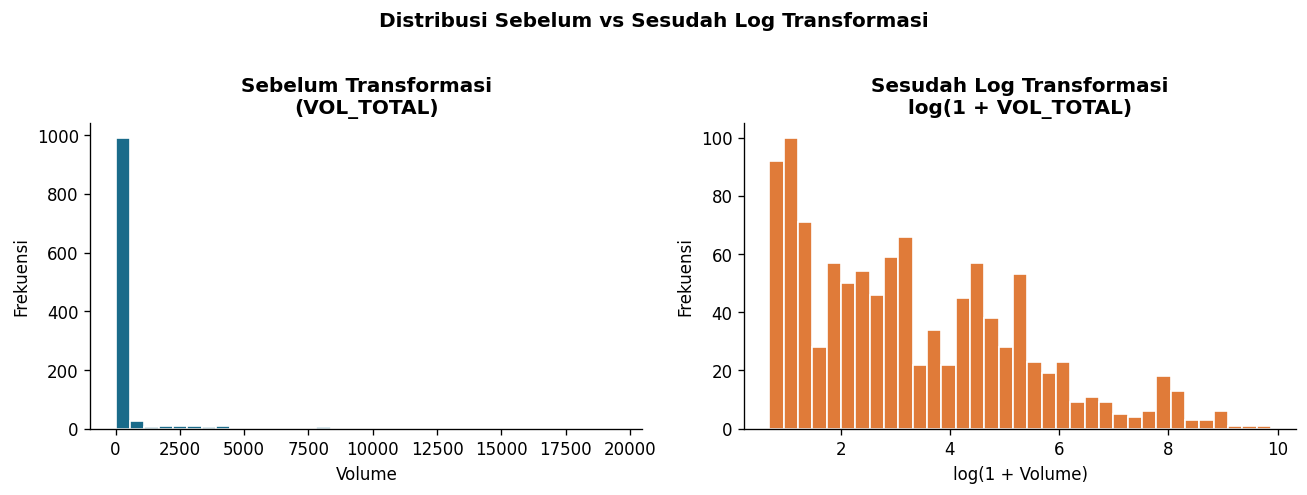

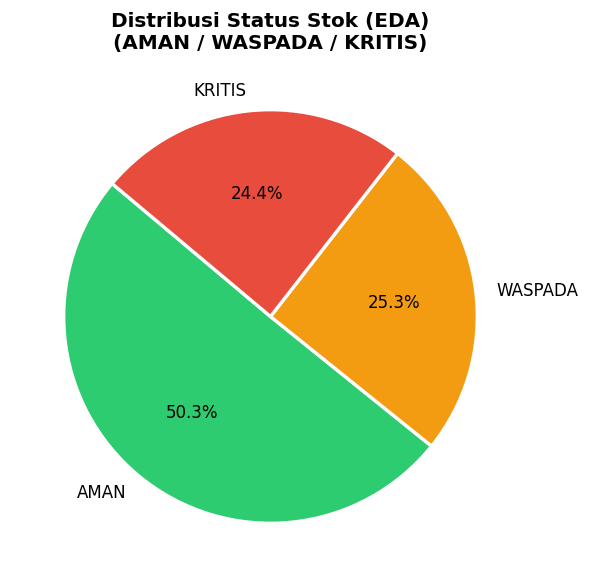

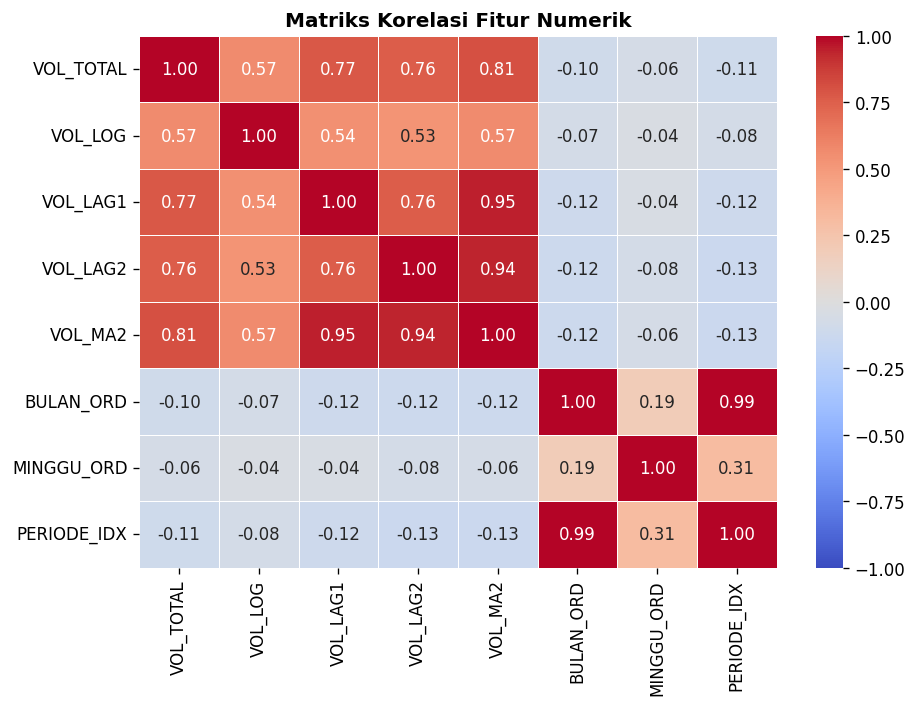

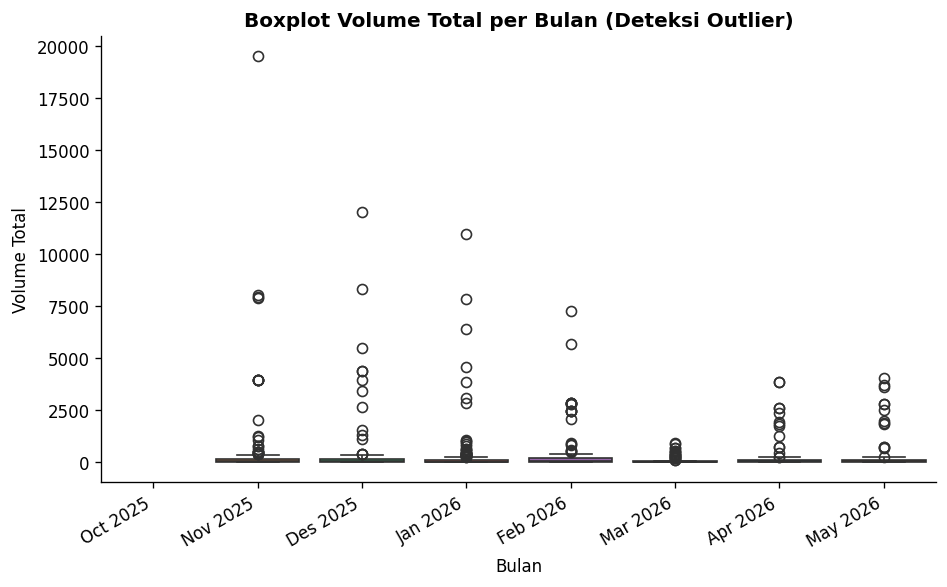

Data siap model tersimpan: df_model_ready.csv

BAGIAN 2 SELESAI


In [11]:

"""
=============================================================
BAGIAN 2: PRAPROSES DATA & REKAYASA FITUR
=============================================================
Sistem Monitoring Stok & Penjadwalan Produksi – Program MBG
Mata Kuliah  : Perancangan Aplikasi Sains Data
Kelompok     : Pahlawan MBG
Universitas  : Telkom University

Input  : raw_df_rekap.csv  (output Bagian 1)
Output bagian ini:
  - Deskripsi data sebelum & sesudah praproses
  - Log transformasi
  - Feature Engineering (lag, MA, label stok)
  - df_model_ready.csv  → dipakai Bagian 3
=============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#1a6b8a', '#e07b39', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
OUTPUT_DIR = "/mnt/user-data/outputs/" # Updated path

# ==============================================================
# 2.1  LOAD DATA (dari Bagian 1)
# ==============================================================
print("=" * 60)
print("2.1  LOAD DATA DARI BAGIAN 1")
print("=" * 60)

df_rekap = pd.read_csv(OUTPUT_DIR + "raw_df_rekap.csv")
print(f"Data dimuat: {df_rekap.shape[0]} baris, {df_rekap.shape[1]} kolom")

# ==============================================================
# 2.2  DESKRIPSI DATA SEBELUM PRAPROSES
# ==============================================================
print("\n" + "=" * 60)
print("2.2  DESKRIPSI DATA SEBELUM PRAPROSES")
print("=" * 60)

print(f"\n── Info Kolom ──")
print(df_rekap.dtypes.to_string())

print(f"\n── Nilai Hilang (Missing Values) ──")
missing = df_rekap.isnull().sum()
missing_pct = (df_rekap.isnull().mean() * 100).round(2)
print(pd.DataFrame({'Jumlah': missing, 'Persentase (%)': missing_pct}).to_string())

print(f"\n── Statistik Deskriptif VOL (termasuk nol) ──")
print(df_rekap['VOL'].describe().round(2).to_string())

print(f"\n── Jumlah Baris VOL = 0  : {(df_rekap['VOL'] == 0).sum()} "
      f"({(df_rekap['VOL'] == 0).mean()*100:.1f}%)")
print(f"── Jumlah Item Unik      : {df_rekap['ITEM'].nunique()}")
print(f"── Jumlah Baris Total    : {len(df_rekap)}")

print(f"\n── Distribusi Satuan (SAT) ──")
print(df_rekap['SAT'].value_counts().head(12).to_string())

# ==============================================================
# 2.3  LOG TRANSFORMASI & PEMBERSIHAN
# ==============================================================
print("\n" + "=" * 60)
print("2.3  LOG TRANSFORMASI & PEMBERSIHAN DATA")
print("=" * 60)

print("""
Transformasi yang dilakukan:
  T1. Hapus baris VOL = 0  → tidak ada pembelian pada periode tsb
  T2. Normalisasi nama ITEM → hilangkan varian merek (misal Beras JBS → Beras)
  T3. Standarisasi kolom SAT → huruf kecil
  T4. Encode BULAN & MINGGU menjadi ordinal numerik
  T5. Hitung PERIODE_IDX (indeks waktu linier untuk time-series)
  T6. Log Transformasi VOL: VOL_LOG = log(1 + VOL)
      Alasan: distribusi VOL sangat right-skewed (max=12000, median=21)
              → log transform menstabilkan variance & mempermudah regresi
""")

# T1 – Hapus VOL = 0
df_clean = df_rekap[df_rekap['VOL'] > 0].copy()
print(f"T1 – Setelah hapus VOL=0 : {len(df_rekap)} → {len(df_clean)} baris")

# T2 – Normalisasi nama item
item_norm = {
    'Beras Jbs'                  : 'Beras',
    'Beras'                      : 'Beras',
    'Dorry Nasuba'               : 'Dorry',
    'Dorry'                      : 'Dorry',
    'Vetsin Ajinomoto'           : 'Vetsin',
    'Vetsin'                     : 'Vetsin',
    'Garam Dolphin'              : 'Garam',
    'Garam'                      : 'Garam',
    'Lada Bubuk Ladaku'          : 'Lada Bubuk',
    'Lada Bubuk'                 : 'Lada Bubuk',
    'Minyak Fortune'             : 'Minyak',
    'Minyak Sunco'               : 'Minyak',
    'Tepung Terigu Segitiga Biru': 'Tepung Terigu',
    'Tepung Terigu'              : 'Tepung Terigu',
    'Roycko Ayam'                : 'Roycko',
    'Roycko'                     : 'Roycko',
}
df_clean['ITEM_NORM'] = df_clean['ITEM'].replace(item_norm).fillna(df_clean['ITEM'])
n_before = df_clean['ITEM'].nunique()
n_after  = df_clean['ITEM_NORM'].nunique()
print(f"T2 – Normalisasi nama item: {n_before} → {n_after} item unik")

# T3 – Standarisasi SAT
df_clean['SAT'] = df_clean['SAT'].astype(str).str.lower().str.strip()

# T4 – Encode BULAN & MINGGU
urutan_bulan = ['Oct 2025', 'Nov 2025', 'Des 2025', 'Jan 2026', 'Feb 2026', 'Mar 2026', 'Apr 2026', 'May 2026'] # Updated urutan_bulan
df_clean['BULAN_ORD']  = df_clean['BULAN'].map({b: i+1 for i,b in enumerate(urutan_bulan)})
df_clean['MINGGU_ORD'] = df_clean['MINGGU'].map({'W1':1,'W2':2,'W3':3,'W4':4})

# T5 – PERIODE_IDX (indeks waktu linier)
df_clean['PERIODE_IDX'] = (df_clean['BULAN_ORD'] - 1) * 4 + df_clean['MINGGU_ORD']
print(f"T4-T5 – Range PERIODE_IDX: {df_clean['PERIODE_IDX'].min()} – {df_clean['PERIODE_IDX'].max()}")

# T6 – Log Transformasi
df_clean['VOL_LOG'] = np.log1p(df_clean['VOL'])
print(f"T6 – VOL_LOG: mean={df_clean['VOL_LOG'].mean():.3f}, "
      f"std={df_clean['VOL_LOG'].std():.3f}")

# ==============================================================
# 2.4  DESKRIPSI DATA SESUDAH PRAPROSES
# ==============================================================
print("\n" + "=" * 60)
print("2.4  DESKRIPSI DATA SESUDAH PRAPROSES")
print("=" * 60)

print(f"Jumlah baris           : {len(df_clean)}")
print(f"Jumlah item unik       : {df_clean['ITEM_NORM'].nunique()}")
print(f"Missing values (total) : {df_clean.isnull().sum().sum()}")
print(f"Kolom baru yang dibuat : ITEM_NORM, BULAN_ORD, MINGGU_ORD, PERIODE_IDX, VOL_LOG")

print(f"\n── Statistik VOL sesudah praproses (VOL > 0) ──")
print(df_clean['VOL'].describe().round(2).to_string())

print(f"\n── Statistik VOL_LOG ──")
print(df_clean['VOL_LOG'].describe().round(4).to_string())

# ==============================================================
# 2.5  REKAYASA FITUR (FEATURE ENGINEERING)
# ==============================================================
print("\n" + "=" * 60)
print("2.5  REKAYASA FITUR (FEATURE ENGINEERING)")
print("=" * 60)

print("""
Fitur yang dibuat:
  F1. Agregasi per item-periode → 1 baris per (ITEM_NORM, PERIODE_IDX)
  F2. VOL_LAG1  : volume pembelian 1 periode sebelumnya (fitur time-series)
  F3. VOL_LAG2  : volume pembelian 2 periode sebelumnya
  F4. VOL_MA2   : moving average 2 periode (rata-rata lag1 + lag2)
  F5. STATUS_STOK : label klasifikasi berdasarkan kuartil volume

  Definisi kelas STATUS_STOK:
    - AMAN    : VOL >= Q2 (median train)
    - WASPADA : Q1 <= VOL < Q2
    - KRITIS  : VOL < Q1
""")

# F1 – Agregasi
df_agg = (df_clean.groupby(['ITEM_NORM','BULAN_ORD','MINGGU_ORD','PERIODE_IDX'])
                  .agg(VOL_TOTAL=('VOL','sum'), VOL_LOG=('VOL_LOG','mean'))
                  .reset_index()
                  .sort_values(['ITEM_NORM','PERIODE_IDX']))

# F2-F4 – Lag & Moving Average
df_agg['VOL_LAG1'] = df_agg.groupby('ITEM_NORM')['VOL_TOTAL'].shift(1)
df_agg['VOL_LAG2'] = df_agg.groupby('ITEM_NORM')['VOL_TOTAL'].shift(2)
df_agg['VOL_MA2']  = df_agg.groupby('ITEM_NORM')['VOL_TOTAL'].transform(
                        lambda x: x.shift(1).rolling(2, min_periods=1).mean())

# F5 – Label STATUS_STOK sementara (hanya untuk visualisasi di Bagian 2)
# Label final akan dibuat ulang dari threshold train di Bagian 3
Q1_all = df_agg['VOL_TOTAL'].quantile(0.25)
Q2_all = df_agg['VOL_TOTAL'].quantile(0.50)

def label_stok(v, q1, q2):
    if v >= q2: return 'AMAN'
    elif v >= q1: return 'WASPADA'
    else: return 'KRITIS'

df_agg['STATUS_STOK'] = df_agg['VOL_TOTAL'].apply(
    lambda v: label_stok(v, Q1_all, Q2_all))


print(f"\n── Distribusi Label STATUS_STOK ──")
print(df_agg['STATUS_STOK'].value_counts().to_string())

print(f"\n── Sampel Data Siap Model (5 baris) ──")
print(df_agg.head().to_string(index=False))
print(f"Total sampel setelah agregasi   : {len(df_agg)}")
print(f"Sampel dengan lag lengkap       : {df_agg.dropna(subset=['VOL_LAG1','VOL_LAG2']).shape[0]}")

# ==============================================================
# 2.6  VISUALISASI PRAPROSES
# ==============================================================
print("\n" + "=" * 60)
print("2.6  VISUALISASI PRAPROSES")
print("=" * 60)

## ── 2.6.1  Sebelum vs Sesudah Log Transform ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_agg['VOL_TOTAL'], bins=35, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Sebelum Transformasi\n(VOL_TOTAL)', fontweight='bold')
axes[0].set_xlabel('Volume')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df_agg['VOL_LOG'], bins=35, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Sesudah Log Transformasi\nlog(1 + VOL_TOTAL)', fontweight='bold')
axes[1].set_xlabel('log(1 + Volume)')
axes[1].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Sebelum vs Sesudah Log Transformasi',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## ── 2.6.2  Pie Chart Distribusi Status Stok ────────────────
stok_counts = df_agg['STATUS_STOK'].value_counts()
colors_pie  = {'AMAN': '#2ecc71', 'WASPADA': '#f39c12', 'KRITIS': '#e74c3c'}
colors_list = [colors_pie[c] for c in stok_counts.index]

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    stok_counts.values,
    labels=stok_counts.index,
    autopct='%1.1f%%',
    colors=colors_list,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title('Distribusi Status Stok (EDA)\n(AMAN / WASPADA / KRITIS)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## ── 2.6.3  Korelasi Fitur Numerik ─────────────────────
feat_corr = ['VOL_TOTAL','VOL_LOG','VOL_LAG1','VOL_LAG2','VOL_MA2',
             'BULAN_ORD','MINGGU_ORD','PERIODE_IDX']
corr_matrix = df_agg[feat_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            linecolor='white', ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriks Korelasi Fitur Numerik',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## ── 2.6.4  Boxplot Outlier VOL_TOTAL per Bulan ─────────────
fig, ax = plt.subplots(figsize=(8, 5))
bulan_map_display = {i+1: bulan for i, bulan in enumerate(urutan_bulan)} # Dynamically create map
df_agg['BULAN_LABEL'] = df_agg['BULAN_ORD'].map(bulan_map_display)
sns.boxplot(data=df_agg, x='BULAN_LABEL', y='VOL_TOTAL',
            palette=PALETTE[:len(urutan_bulan)], ax=ax, order=urutan_bulan) # Use urutan_bulan for order
ax.set_title('Boxplot Volume Total per Bulan (Deteksi Outlier)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Volume Total')
plt.xticks(rotation=30, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# ==============================================================
# 2.7  SIMPAN DATA SIAP MODEL UNTUK BAGIAN 3
# ==============================================================
df_agg.to_csv(OUTPUT_DIR + "df_model_ready.csv", index=False)
print(f"Data siap model tersimpan: df_model_ready.csv")

print("\n" + "=" * 60)
print("BAGIAN 2 SELESAI")
print("=" * 60)


3.1  LOAD DATA DARI BAGIAN 2
Data dimuat: 1077 baris, 11 kolom
Kolom: ['ITEM_NORM', 'BULAN_ORD', 'MINGGU_ORD', 'PERIODE_IDX', 'VOL_TOTAL', 'VOL_LOG', 'VOL_LAG1', 'VOL_LAG2', 'VOL_MA2', 'STATUS_STOK', 'BULAN_LABEL']

3.2  ANALISIS PEMILIHAN ALGORITMA

┌──────────────────────────────────────────────────────────┐
│  PROBLEM A: FORECASTING VOLUME BAHAN (REGRESI)           │
│  Target  : VOL_TOTAL                                     │
│  Fitur   : PERIODE_IDX, BULAN_ORD, MINGGU_ORD,           │
│            VOL_LAG1, VOL_LAG2, VOL_MA2                   │
├──────────────────────────────────────────────────────────┤
│  Kandidat algoritma:                                     │
│  1. Linear Regression  → baseline sederhana              │
│  2. Ridge Regression   → baseline + regularisasi L2      │
│  3. Random Forest      → ensemble, cocok data kecil      │
│                                                          │
│  Alasan: data time-series mingguan, ukuran kecil →       │
│  mulai linear s

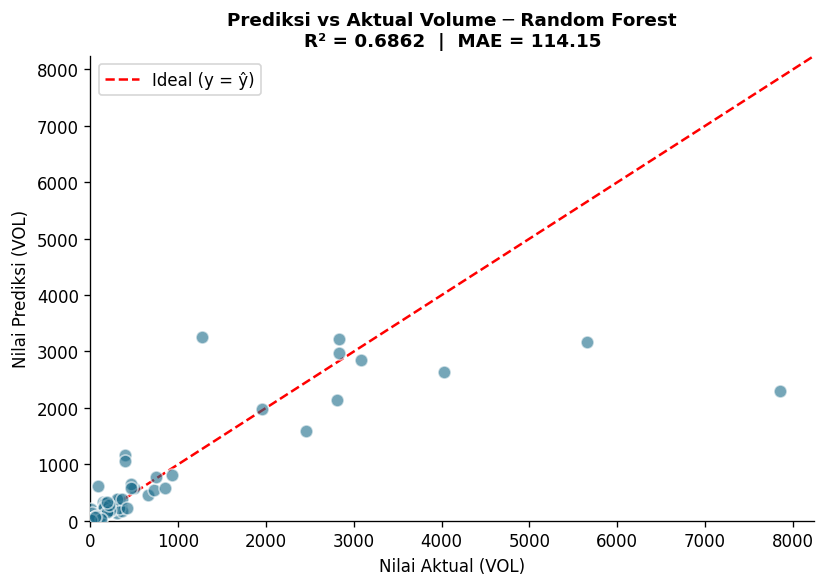

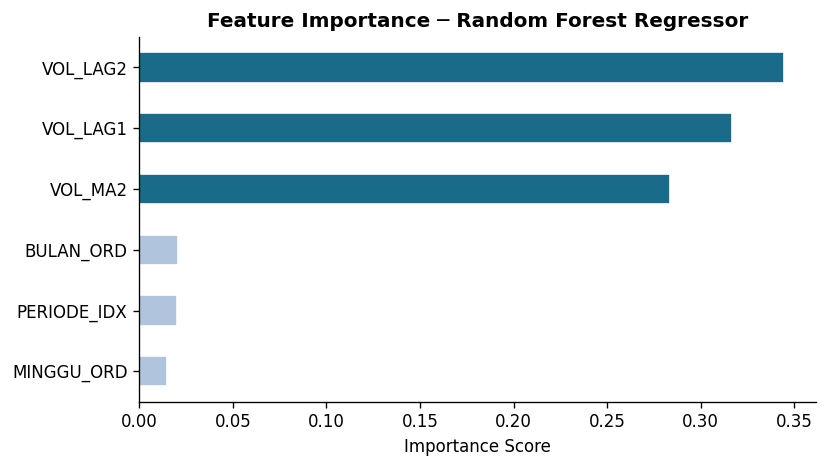

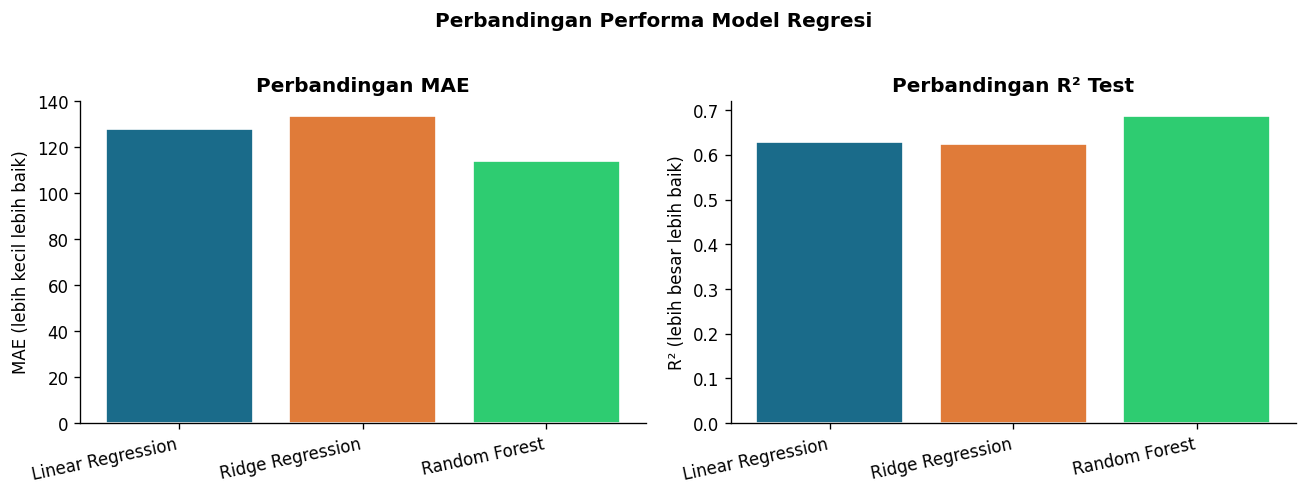


3.5  MODEL B: KLASIFIKASI STATUS STOK (Aman/Awas/Bahaya)

── Decision Tree ──
Accuracy Train : 0.8646 | Test: 0.8162 | CV: 0.8133
              precision    recall  f1-score   support

        Aman       0.94      0.84      0.89        94
        Awas       0.67      0.81      0.73        58
      Bahaya       0.81      0.76      0.78        33

    accuracy                           0.82       185
   macro avg       0.81      0.80      0.80       185
weighted avg       0.83      0.82      0.82       185


── Gradient Boosting ──
Accuracy Train : 0.9206 | Test: 0.8324 | CV: 0.8214
              precision    recall  f1-score   support

        Aman       0.90      0.93      0.91        94
        Awas       0.75      0.71      0.73        58
      Bahaya       0.79      0.79      0.79        33

    accuracy                           0.83       185
   macro avg       0.81      0.81      0.81       185
weighted avg       0.83      0.83      0.83       185


 Model terbaik (klasifikasi):

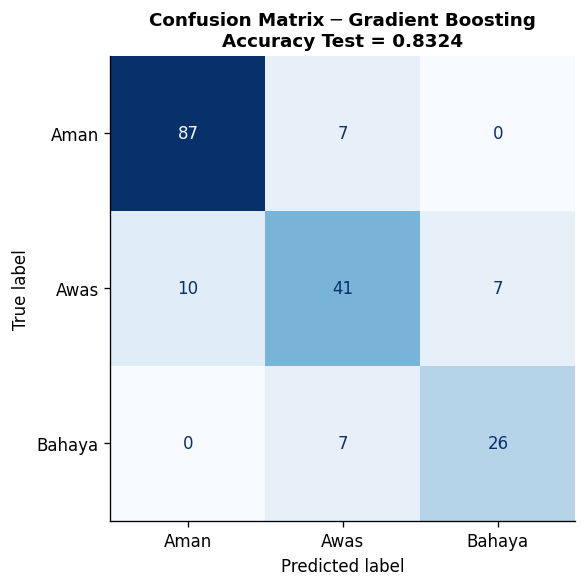

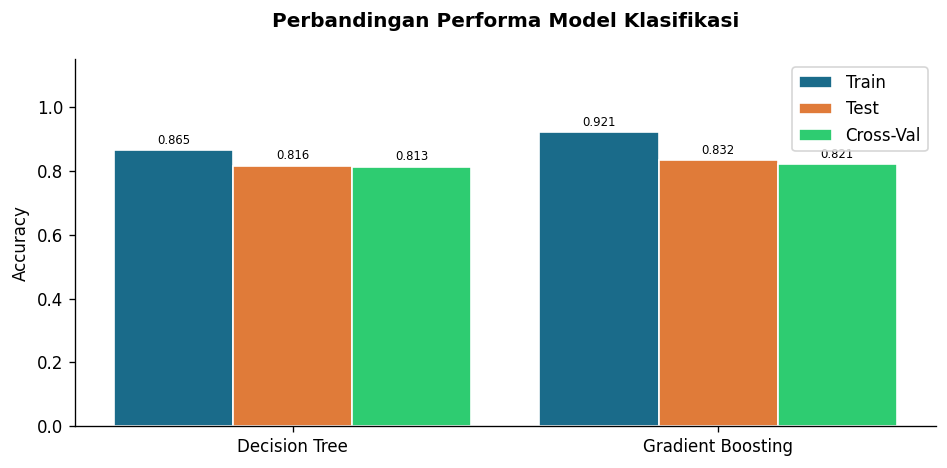


3.6  OUTPUT & INTERPRETASI MODEL

╔══════════════════════════════════════════════════════════╗
║  RINGKASAN HASIL EKSPERIMEN & PARAMETER OPTIMAL          ║
╟══════════════════════════════════════════════════════════╡
║  MODEL A ─ Regresi Volume (Forecasting)                  ║
║  • Algoritma terpilih : Random Forest                 ║
║  • R² test            : 0.6862                        ║
║  • MAE                : 114.15                        ║
╟══════════════════════════════════════════════════════════╡
║  MODEL B ─ Klasifikasi Status Stok                       ║
║  • Algoritma terpilih : Gradient Boosting             ║
║  • Accuracy test      : 0.8324                        ║
║  • CV Accuracy        : 0.8214                        ║
╚══════════════════════════════════════════════════════════╝

3.7  SIMULASI PREDIKSI RESTOCK PERIODE BERIKUTNYA

Top 20 prediksi restock:

                  Item  Vol_Periode_Terakhir  Prediksi_Vol_Berikutnya  Selisih Status_Prediksi
                 

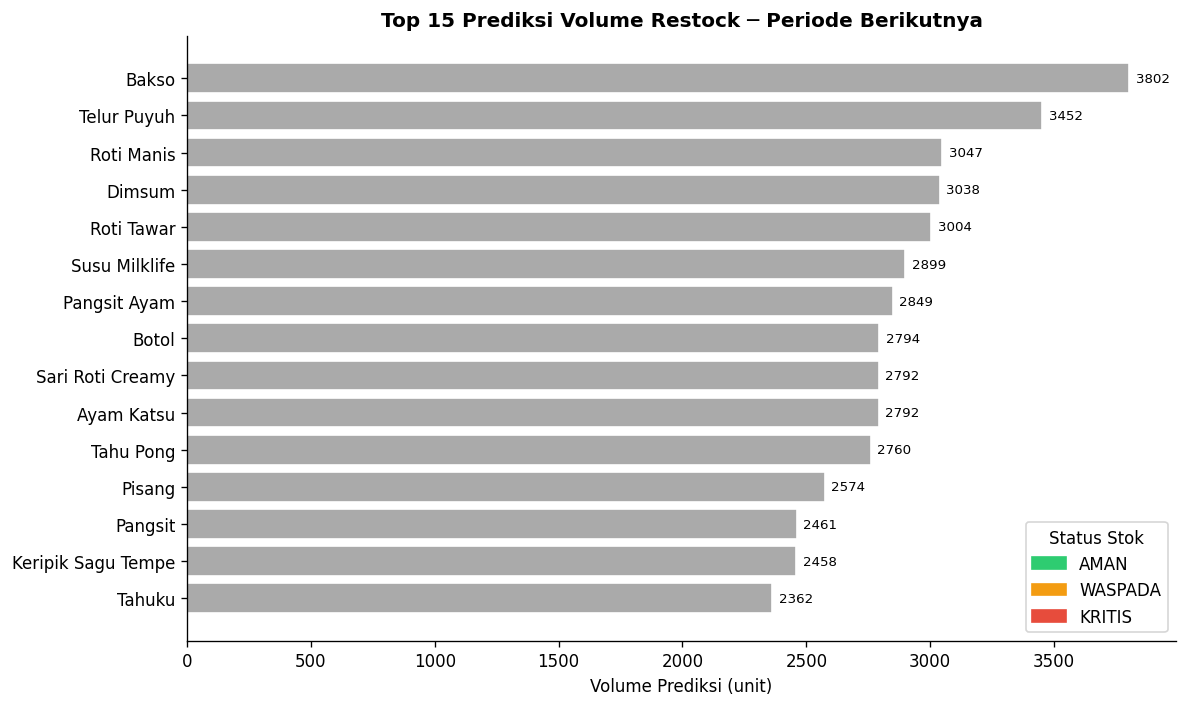

Prediksi tersimpan: prediksi_restock.csv  (206 item)

BAGIAN 3 SELESAI
✅ Semua artifact tersimpan:
  model_klasifikasi.pkl          187.4 KB
  label_encoder.pkl              0.5 KB
  model_regresi.pkl              531.2 KB
  feat_reg.pkl                   0.1 KB
  feat_clf.pkl                   0.1 KB
  scaler.pkl                     1.1 KB


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#1a6b8a', '#e07b39', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
OUTPUT_DIR = "/mnt/user-data/outputs/"

# ==============================================================
# 3.1  LOAD DATA DARI BAGIAN 2
# ==============================================================
print("=" * 60)
print("3.1  LOAD DATA DARI BAGIAN 2")
print("=" * 60)

df = pd.read_csv(OUTPUT_DIR + "df_model_ready.csv")
print(f"Data dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Kolom: {df.columns.tolist()}")

# ==============================================================
# 3.2  ANALISIS PEMILIHAN ALGORITMA
# ==============================================================
print("\n" + "=" * 60)
print("3.2  ANALISIS PEMILIHAN ALGORITMA")
print("=" * 60)

print("""
┌──────────────────────────────────────────────────────────┐
│  PROBLEM A: FORECASTING VOLUME BAHAN (REGRESI)           │
│  Target  : VOL_TOTAL                                     │
│  Fitur   : PERIODE_IDX, BULAN_ORD, MINGGU_ORD,           │
│            VOL_LAG1, VOL_LAG2, VOL_MA2                   │
├──────────────────────────────────────────────────────────┤
│  Kandidat algoritma:                                     │
│  1. Linear Regression  → baseline sederhana              │
│  2. Ridge Regression   → baseline + regularisasi L2      │
│  3. Random Forest      → ensemble, cocok data kecil      │
│                                                          │
│  Alasan: data time-series mingguan, ukuran kecil →       │
│  mulai linear sebagai baseline, RF untuk perbandingan    │
└──────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────┐
│  PROBLEM B: KLASIFIKASI STATUS STOK                      │
│  Target  : STATUS_STOK (AMAN / WASPADA / KRITIS)         │
│  Fitur   : VOL_LAG1, VOL_LAG2, VOL_MA2,                  │
│            BULAN_ORD, MINGGU_ORD                         │
│                                                          │
├──────────────────────────────────────────────────────────┤
│  Kandidat algoritma:                                     │
│  1. Decision Tree      → interpretable, visualisable     │
│  2. Gradient Boosting  → akurasi lebih tinggi            │
│                                                          │
│  Alasan: output digunakan sbg indikator traffic-light    │
│  dashboard → interpretabilitas sangat penting            │
└──────────────────────────────────────────────────────────┘
""")

# ==============================================================
# 3.3  PERSIAPAN DATA MODEL (dengan label Aman/Awas/Bahaya)
# ==============================================================
print("=" * 60)
print("3.3  PERSIAPAN DATA MODEL")
print("=" * 60)

df_model = df.dropna(subset=['VOL_LAG1', 'VOL_LAG2', 'VOL_MA2']).copy()

# Fitur Regresi
FEAT_REG   = ['PERIODE_IDX', 'BULAN_ORD', 'MINGGU_ORD', 'VOL_LAG1', 'VOL_LAG2', 'VOL_MA2']
TARGET_REG = 'VOL_TOTAL'
X_reg = df_model[FEAT_REG]
y_reg = df_model[TARGET_REG]

X_reg_full = df_model[FEAT_REG]
y_reg_full = df_model[TARGET_REG]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg_full, y_reg_full, test_size=0.25, random_state=42)

# Hitung threshold HANYA dari data train
Q1_train = y_tr.quantile(0.25)
Q2_train = y_tr.quantile(0.50)

# Fitur klasifikasi
FEAT_CLF   = ['VOL_LAG1', 'VOL_LAG2', 'VOL_MA2', 'BULAN_ORD', 'MINGGU_ORD']

# Definisikan label dengan nama: Aman, Awas, Bahaya
def label_stok(v, q1, q2):
    if v >= q2:
        return 'Aman'
    elif v >= q1:
        return 'Awas'
    else:
        return 'Bahaya'

df_model['STATUS_STOK_FIXED'] = df_model[TARGET_REG].apply(
    lambda v: label_stok(v, Q1_train, Q2_train))

TARGET_CLF = 'STATUS_STOK_FIXED'

# Klasifikasi split
le = LabelEncoder()
X_clf = df_model[FEAT_CLF]
y_clf = le.fit_transform(df_model[TARGET_CLF])

# Split dengan stratify
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf)

# Scaling untuk model linear
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

print(f"\nDataset regresi     → Train: {X_tr.shape[0]}, Test: {X_te.shape[0]}, Fitur: {len(FEAT_REG)}")
print(f"Dataset klasifikasi → Train: {Xc_tr.shape[0]}, Test: {Xc_te.shape[0]}, Fitur: {len(FEAT_CLF)}")
print(f"Label kelas: {le.classes_}")  # akan tampil ['Aman', 'Awas', 'Bahaya'] (terurut abjad)
print(f"\nFitur Klasifikasi yang dipakai: {FEAT_CLF}")


# ==============================================================
# 3.4  MODEL A ─ REGRESI VOLUME BAHAN
# ==============================================================
print("\n" + "=" * 60)
print("3.4  MODEL A: FORECASTING VOLUME BAHAN (REGRESI)")
print("=" * 60)

# Ridge: cari alpha terbaik
ridge_params = {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}
gs_ridge = GridSearchCV(Ridge(), ridge_params, cv=3, scoring='r2')
gs_ridge.fit(X_tr_s, y_tr)
best_alpha = gs_ridge.best_params_['alpha']

# RF: cari n_estimators & max_depth
rf_params = {'n_estimators': [50, 100], 'max_depth': [8, 19, 12],'min_samples_split': [10, 15,20],'min_samples_leaf': [4, 6], 'max_features': [0.3, 0.5]}
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2', n_jobs=-1)
gs_rf.fit(X_tr, y_tr)

## ── Training & Evaluasi ──────────────────────────────
models_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=best_alpha),
    'Random Forest'    : gs_rf.best_estimator_,
}

results_reg = {}
for name, mdl in models_reg.items():
    if name == 'Random Forest':
        mdl.fit(X_tr, y_tr)
        pred = mdl.predict(X_te)
        cv_r2 = cross_val_score(mdl, X_reg, y_reg, cv=3, scoring='r2').mean()
    else:
        mdl.fit(X_tr_s, y_tr)
        pred = mdl.predict(X_te_s)
        cv_r2 = cross_val_score(mdl, scaler.transform(X_reg), y_reg, cv=3, scoring='r2').mean()

    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    results_reg[name] = {
        'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
        'R²_test': round(r2, 4), 'R²_cv': round(cv_r2, 4)
    }

print(f"\n── Hasil Evaluasi Model Regresi ──")
df_res_reg = pd.DataFrame(results_reg).T.reset_index().rename(columns={'index':'Model'})
print(df_res_reg.to_string(index=False))

best_reg_name = max(results_reg, key=lambda k: results_reg[k]['R²_test'])
print(f"\n Model terbaik (regresi): {best_reg_name}")

## ── Visualisasi Regresi ──────────────────────────────
best_reg_mdl = models_reg[best_reg_name]
pred_best = (best_reg_mdl.predict(X_te)
             if best_reg_name == 'Random Forest'
             else best_reg_mdl.predict(X_te_s))

# Plot prediksi vs aktual
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_te, pred_best, alpha=0.6, color=PALETTE[0], edgecolors='white', s=60, zorder=3)
lims = [0, max(y_te.max(), pred_best.max()) * 1.05]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y = ŷ)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Nilai Aktual (VOL)')
ax.set_ylabel('Nilai Prediksi (VOL)')
ax.set_title(f'Prediksi vs Aktual Volume ─ {best_reg_name}\n'
             f'R² = {results_reg[best_reg_name]["R²_test"]}  |  '
             f'MAE = {results_reg[best_reg_name]["MAE"]}',
             fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Feature Importance (Random Forest)
rf_mdl = models_reg['Random Forest']
fi = pd.Series(rf_mdl.feature_importances_, index=FEAT_REG).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
colors_fi = [PALETTE[0] if v >= fi.median() else '#b0c4de' for v in fi.values]
fi.plot(kind='barh', color=colors_fi, ax=ax, edgecolor='white')
ax.set_title('Feature Importance ─ Random Forest Regressor',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Perbandingan MAE & R² semua model regresi (bar chart)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = list(results_reg.keys())
maes  = [results_reg[n]['MAE'] for n in names]
r2s   = [results_reg[n]['R²_test'] for n in names]

axes[0].bar(names, maes, color=PALETTE[:3], edgecolor='white')
axes[0].set_title('Perbandingan MAE', fontweight='bold')
axes[0].set_ylabel('MAE (lebih kecil lebih baik)')
axes[0].set_xticklabels(names, rotation=12, ha='right')

axes[1].bar(names, r2s, color=PALETTE[:3], edgecolor='white')
axes[1].set_title('Perbandingan R² Test', fontweight='bold')
axes[1].set_ylabel('R² (lebih besar lebih baik)')
axes[1].set_xticklabels(names, rotation=12, ha='right')

plt.suptitle('Perbandingan Performa Model Regresi', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==============================================================
# 3.5  MODEL B ─ KLASIFIKASI STATUS STOK (Aman/Awas/Bahaya)
# ==============================================================
print("\n" + "=" * 60)
print("3.5  MODEL B: KLASIFIKASI STATUS STOK (Aman/Awas/Bahaya)")
print("=" * 60)

# Hyperparameter tuning
dt_params = {'max_depth': [3, 4, 5, None], 'min_samples_split': [2, 5, 10]}
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     dt_params, cv=3, scoring='accuracy')
gs_dt.fit(Xc_tr, yc_tr)

gb_params = {'n_estimators': [30, 50, 70], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3], 'min_samples_split': [5, 10]}
gs_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                     gb_params, cv=3, scoring='accuracy')
gs_gb.fit(Xc_tr, yc_tr)

models_clf = {
    'Decision Tree'    : gs_dt.best_estimator_,
    'Gradient Boosting': gs_gb.best_estimator_,
}

results_clf = {}
for name, mdl in models_clf.items():
    mdl.fit(Xc_tr, yc_tr)
    pred_tr = mdl.predict(Xc_tr)
    pred_te = mdl.predict(Xc_te)
    cv_acc  = cross_val_score(mdl, X_clf, y_clf, cv=3, scoring='accuracy').mean()
    acc_tr  = accuracy_score(yc_tr, pred_tr)
    acc_te  = accuracy_score(yc_te, pred_te)
    results_clf[name] = {
        'Acc_Train': round(acc_tr, 4),
        'Acc_Test' : round(acc_te, 4),
        'CV_Acc'   : round(cv_acc, 4),
    }
    print(f"\n── {name} ──")
    print(f"Accuracy Train : {acc_tr:.4f} | Test: {acc_te:.4f} | CV: {cv_acc:.4f}")
    print(classification_report(yc_te, pred_te, target_names=le.classes_))

best_clf_name = max(results_clf, key=lambda k: results_clf[k]['CV_Acc'])
print(f"\n Model terbaik (klasifikasi): {best_clf_name}")

# Confusion Matrix dengan label Aman/Awas/Bahaya
best_clf_mdl = models_clf[best_clf_name]
pred_clf     = best_clf_mdl.predict(Xc_te)

fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(yc_te, pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix ─ {best_clf_name}\n'
             f'Accuracy Test = {results_clf[best_clf_name]["Acc_Test"]}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Perbandingan akurasi
fig, ax = plt.subplots(figsize=(8, 4))
names_clf = list(results_clf.keys())
x         = np.arange(len(names_clf))
width     = 0.28
metrics   = ['Acc_Train', 'Acc_Test', 'CV_Acc']
labels_m  = ['Train', 'Test', 'Cross-Val']
for i, (m, lbl) in enumerate(zip(metrics, labels_m)):
    vals = [results_clf[n][m] for n in names_clf]
    ax.bar(x + i*width, vals, width, label=lbl, color=PALETTE[i], edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(names_clf)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Perbandingan Performa Model Klasifikasi\n', fontsize=12, fontweight='bold')
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

# ==============================================================
# 3.6  OUTPUT & INTERPRETASI MODEL
# ==============================================================
print("\n" + "=" * 60)
print("3.6  OUTPUT & INTERPRETASI MODEL")
print("=" * 60)

print(f"""
╔══════════════════════════════════════════════════════════╗
║  RINGKASAN HASIL EKSPERIMEN & PARAMETER OPTIMAL          ║
╟══════════════════════════════════════════════════════════╡
║  MODEL A ─ Regresi Volume (Forecasting)                  ║
║  • Algoritma terpilih : {best_reg_name:<30}║
║  • R² test            : {results_reg[best_reg_name]['R²_test']:<30}║
║  • MAE                : {results_reg[best_reg_name]['MAE']:<30}║
╟══════════════════════════════════════════════════════════╡
║  MODEL B ─ Klasifikasi Status Stok                       ║
║  • Algoritma terpilih : {best_clf_name:<30}║
║  • Accuracy test      : {results_clf[best_clf_name]['Acc_Test']:<30}║
║  • CV Accuracy        : {results_clf[best_clf_name]['CV_Acc']:<30}║
╚══════════════════════════════════════════════════════════╝
""")


# ==============================================================
# 3.7  SIMULASI PREDIKSI RESTOCK PERIODE BERIKUTNYA
# ==============================================================
print("=" * 60)
print("3.7  SIMULASI PREDIKSI RESTOCK PERIODE BERIKUTNYA")
print("=" * 60)

# Ambil data terakhir tiap item sebagai basis prediksi
df_last = (df.sort_values('PERIODE_IDX')
             .groupby('ITEM_NORM').last()
             .reset_index())

df_last['PERIODE_IDX_N'] = df_last['PERIODE_IDX'] + 1
df_last['BULAN_ORD_N']   = ((df_last['PERIODE_IDX_N'] - 1) // 4) + 1
df_last['MINGGU_ORD_N']  = ((df_last['PERIODE_IDX_N'] - 1) % 4)  + 1
df_last['VOL_LAG1_N']    = df_last['VOL_TOTAL']
df_last['VOL_LAG2_N']    = df_last['VOL_LAG1'].fillna(df_last['VOL_TOTAL'])
df_last['VOL_MA2_N']     = df_last['VOL_MA2'].fillna(df_last['VOL_TOTAL'])

X_next = df_last[['PERIODE_IDX_N','BULAN_ORD_N','MINGGU_ORD_N',
                   'VOL_LAG1_N','VOL_LAG2_N','VOL_MA2_N']]
X_next.columns = FEAT_REG

rf_final  = models_reg['Random Forest']
vol_pred  = np.round(rf_final.predict(X_next).clip(min=0)).astype(int)

# Prediksi status stok (menggunakan fitur lag saja, konsisten dengan training)
clf_final = models_clf[best_clf_name]
X_for_clf = pd.DataFrame({
    'VOL_LAG1'  : df_last['VOL_TOTAL'].values,          # lag1 = periode terakhir
    'VOL_LAG2'  : df_last['VOL_LAG1'].fillna(df_last['VOL_TOTAL']).values,
    'VOL_MA2'   : df_last['VOL_MA2'].fillna(df_last['VOL_TOTAL']).values,
    'BULAN_ORD' : df_last['BULAN_ORD_N'].values,
    'MINGGU_ORD': df_last['MINGGU_ORD_N'].values,
})
X_for_clf.columns = FEAT_CLF
status_pred = le.inverse_transform(clf_final.predict(X_for_clf))

df_forecast = pd.DataFrame({
    'Item'                   : df_last['ITEM_NORM'],
    'Vol_Periode_Terakhir'   : df_last['VOL_TOTAL'].astype(int),
    'Prediksi_Vol_Berikutnya': vol_pred,
    'Selisih'                : vol_pred - df_last['VOL_TOTAL'].astype(int),
    'Status_Prediksi'        : status_pred,
})

df_forecast = df_forecast.sort_values('Prediksi_Vol_Berikutnya', ascending=False)
print(f"\nTop 20 prediksi restock:\n")
print(df_forecast.head(20).to_string(index=False))

# Visualisasi: Top 15 prediksi dengan warna status
fig, ax = plt.subplots(figsize=(10, 6))
top15_fc = df_forecast.head(15)
color_status = {'AMAN':'#2ecc71', 'WASPADA':'#f39c12', 'KRITIS':'#e74c3c'}
bar_colors = [color_status.get(s, '#aaa') for s in top15_fc['Status_Prediksi']]
bars = ax.barh(top15_fc['Item'][::-1],
               top15_fc['Prediksi_Vol_Berikutnya'][::-1],
               color=bar_colors[::-1], edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=8)
ax.set_xlabel('Volume Prediksi (unit)')
ax.set_title('Top 15 Prediksi Volume Restock ─ Periode Berikutnya',
             fontsize=12, fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in color_status.items()]
ax.legend(handles=patches, title='Status Stok', loc='lower right')
plt.tight_layout()
plt.show()

# Simpan ke CSV
df_forecast.to_csv(OUTPUT_DIR + "prediksi_restock.csv", index=False)
print(f"Prediksi tersimpan: prediksi_restock.csv  ({len(df_forecast)} item)")

print("\n" + "=" * 60)
print("BAGIAN 3 SELESAI")
print("=" * 60)

# ==============================================================
# 3.8  SIMPAN MODEL ARTIFACTS
# ==============================================================
import joblib, os

ARTIFACT_DIR = "model_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Model regresi terbaik (Random Forest)
joblib.dump(rf_final,  os.path.join(ARTIFACT_DIR, "model_regresi.pkl"))

# Model klasifikasi terbaik
joblib.dump(clf_final, os.path.join(ARTIFACT_DIR, "model_klasifikasi.pkl"))

# Label encoder & scaler
joblib.dump(le,        os.path.join(ARTIFACT_DIR, "label_encoder.pkl"))
joblib.dump(scaler,    os.path.join(ARTIFACT_DIR, "scaler.pkl"))

# Nama fitur (urutan harus sama persis saat predict)
joblib.dump(FEAT_REG,  os.path.join(ARTIFACT_DIR, "feat_reg.pkl"))
joblib.dump(FEAT_CLF,  os.path.join(ARTIFACT_DIR, "feat_clf.pkl"))

print("✅ Semua artifact tersimpan:")
for f in os.listdir(ARTIFACT_DIR):
    path = os.path.join(ARTIFACT_DIR, f)
    print(f"  {f:30s} {os.path.getsize(path)/1024:.1f} KB")

In [13]:
import shutil
from google.colab import files

# Zip the model_artifacts directory
shutil.make_archive('model_artifacts', 'zip', ARTIFACT_DIR)

# Download the zipped file
files.download('model_artifacts.zip')

print('model_artifacts.zip has been downloaded.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

model_artifacts.zip has been downloaded.
